Analyze and visualize the results of the target reaching experiment

In [7]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt

import path_settings

In [8]:
def loss_path(exp_name, i):
    data_alias = 'D' + str(0).zfill(2)
    method_dir = os.path.join(path_settings.results_dir, exp_name)
    data_dir = os.path.join(method_dir, data_alias + '_' + str(i).zfill(4))
    loss_file_path = os.path.join(data_dir, 'loss.pkl')
    
    return loss_file_path

In [9]:
# def iteration_to_converge(loss, window_size=2, fluctuation_threshold=1e-3):
#     """
#     Determine the iteration at which the optimization process converges.

#     Parameters:
#     - loss (np.ndarray): Array of loss values over iterations.
#     - window_size (int): Number of iterations in the sliding window.
#     - fluctuation_threshold (float): Maximum allowable fluctuation within the window to consider convergence.

#     Returns:
#     - int: The iteration index where convergence occurs, or -1 if no convergence is detected.
#     """
#     for i in range(window_size, len(loss)):
#         window = loss[i - window_size:i]
#         if np.ptp(window) < fluctuation_threshold:  # Check if fluctuation is below the threshold
#             return i
#     return -1

In [10]:
# Tougher convergence criterion
def iteration_to_converge(loss, window_size=3, fluctuation_threshold=2e-3):
    """
    Determine the iteration at which the optimization process converges.

    Parameters:
    - loss (np.ndarray): Array of loss values over iterations.
    - window_size (int): Number of iterations in the sliding window.
    - fluctuation_threshold (float): Maximum allowable fluctuation within the window to consider convergence.

    Returns:
    - int: The iteration index where convergence occurs, or -1 if no convergence is detected.
    """
    n = len(loss)

    for i in range(window_size, n):
        # Check the fluctuation in the current window
        window = loss[i - window_size:i]
        if np.ptp(window) < fluctuation_threshold:  # Fluctuation is below the threshold
            # Ensure all subsequent losses remain within the threshold
            if all(np.ptp(loss[j:j + window_size]) < fluctuation_threshold for j in range(i, n - window_size + 1)):
                return i - window_size + 1

    return -1

In [11]:
# Tougher convergence criterion
def convergence_data(exp_name, data_list, fluctuation_threshold=2e-3):
    loss_lists = []
    converge_list = []
    unconverge_list = []
    count = 0

    for i in data_list:
        loss_file_path = loss_path(exp_name, i)
        with open(loss_file_path, 'rb') as file:
            loss_list = pickle.load(file)
            
            iteration = iteration_to_converge(loss_list, fluctuation_threshold=fluctuation_threshold)
            loss_lists.append(loss_list[-1])
            if iteration == -1:
                count += 1
                unconverge_list.append(i)
            else:
                converge_list.append(iteration)
                # loss_lists.append(loss_list[-1])
            
    loss_array = np.array(loss_lists)
    
    mean = np.mean(loss_array)
    std_dev = np.std(loss_array)
    iteration_mean = np.mean(converge_list)
    converge_rate = (len(data_list) - count) / len(data_list)
    
    q1 = np.percentile(loss_array, 25) # first quartile (Q1, 25th percentile)
    q2 = np.percentile(loss_array, 50) # second quartile (Q2, 50th percentile)
    q3 = np.percentile(loss_array, 75) # third quartile (Q3, 75th percentile)
    IQR = q3 - q1 # Interquartile range
    
    return mean, std_dev, iteration_mean, converge_rate, [q1, q2, q3], IQR, loss_array, unconverge_list

In [12]:
exp_name = "EXP013"
i = 0
fluctuation_threshold = 2

loss_file_path = loss_path(exp_name, i)
with open(loss_file_path, 'rb') as file:
    loss_list = pickle.load(file)
    
    iteration = iteration_to_converge(loss_list, fluctuation_threshold=fluctuation_threshold)
print(loss_list)
print(iteration)

[148.3079860628956, 20.769887073767666, 19.06253231738137, 19.033374352476603, 19.033215921688384, 19.033214668040745, 19.033214660305447, 19.03321466024495, 19.033214660244546, 19.03321466024459, 19.033214660244546]
2


In [13]:
# def convergence_data(exp_name, data_list):
#     loss_lists = []
#     converge_list = []
#     unconverge_list = []
#     count = 0

#     for i in data_list:
#         loss_file_path = loss_path(exp_name, i)
#         with open(loss_file_path, 'rb') as file:
#             loss_list = pickle.load(file)
            
#             iteration = iteration_to_converge(loss_list)
            
#             if iteration == -1:
#                 count += 1
#                 unconverge_list.append(i)
#                 loss_lists.append(loss_list[-1])
#             else:
#                 converge_list.append(iteration)
#                 loss_lists.append(loss_list[iteration])
            
#     loss_array = np.array(loss_lists)
    
#     mean = np.mean(loss_array)
#     std_dev = np.std(loss_array)
#     iteration_mean = np.mean(converge_list)
#     converge_rate = (len(data_list) - count) / len(data_list)
    
#     q1 = np.percentile(loss_array, 25) # first quartile (Q1, 25th percentile)
#     q2 = np.percentile(loss_array, 50) # second quartile (Q2, 50th percentile)
#     q3 = np.percentile(loss_array, 75) # third quartile (Q3, 75th percentile)
#     IQR = q3 - q1 # Interquartile range
    
#     return mean, std_dev, iteration_mean, converge_rate, [q1, q2, q3], IQR, loss_array, unconverge_list

In [14]:
def convergence_data_interpret(exp_name, data_list, fluctuation_threshold=2e-3):
    mean, std_dev, iteration_mean, converge_rate, quartile, IQR, loss_array, unconverge_list = convergence_data(exp_name, data_list, fluctuation_threshold=fluctuation_threshold)
    print(f"Mean loss: {mean}")
    print(f"Standard deviation: {std_dev}")
    print(f"Mean iteration to converge: {iteration_mean}")
    print(f"Convergence rate: {converge_rate}")
    print(f"Quartiles: {quartile}")
    print(f"IQR: {IQR}")
    print(f"Unconverged data: {unconverge_list}")
    
    plt.hist(loss_array, bins=30, color='blue', alpha=0.7, edgecolor='black')
    plt.title("Data Distribution")
    plt.xlabel("Value")
    plt.ylabel("Frequency")
    plt.show()
    
    return loss_array
    

In [15]:
# exp_name = "EXP001"
# data_list = list(range(100))

# mean, std_dev, iteration_mean, converge_rate, quartile, IQR, loss_array = convergence_data(exp_name, data_list)
# print(f"Mean loss: {mean}")
# print(f"Standard deviation: {std_dev}")
# print(f"Mean iteration to converge: {iteration_mean}")
# print(f"Convergence rate: {converge_rate}")
# print(f"Quartiles: {quartile}")
# print(f"IQR: {IQR}")

In [16]:
# plt.hist(loss_array, bins=30, color='blue', alpha=0.7, edgecolor='black')
# plt.title("Data Distribution")
# plt.xlabel("Value")
# plt.ylabel("Frequency")
# plt.show()

Mean loss: 0.0016789762126493244
Standard deviation: 0.0023224051500178736
Mean iteration to converge: 3.5934065934065935
Convergence rate: 0.91
Quartiles: [0.0007538831199483984, 0.001182778064697152, 0.001774334858366063]
IQR: 0.0010204517384176646
Unconverged data: [5, 9, 17, 23, 25, 38, 54, 59, 61]


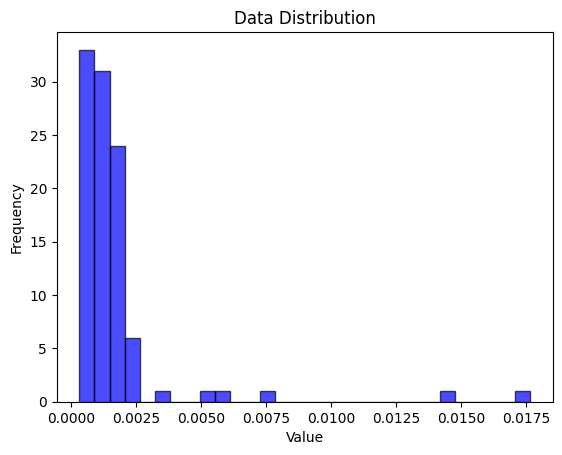

In [17]:
data_list = list(range(100))
loss_1 = convergence_data_interpret("EXP001", data_list)

Mean loss: 0.00031034987939672197
Standard deviation: 0.00015666549618994222
Mean iteration to converge: 3.27
Convergence rate: 1.0
Quartiles: [0.00016653304306390033, 0.00029793186827217094, 0.0004518389202751003]
IQR: 0.00028530587721119997
Unconverged data: []


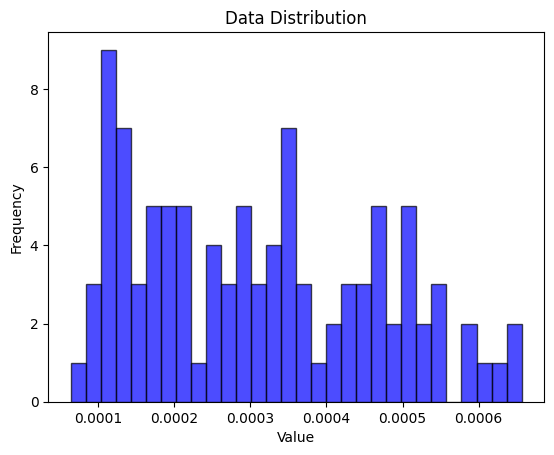

In [18]:
loss_2 = convergence_data_interpret("EXP002", data_list)

Mean loss: 0.002518153350414917
Standard deviation: 0.001933822439172221
Mean iteration to converge: 3.2083333333333335
Convergence rate: 0.96
Quartiles: [0.0012004472942074903, 0.0019996665534214265, 0.003209278978522022]
IQR: 0.0020088316843145317
Unconverged data: [5, 17, 23, 40]


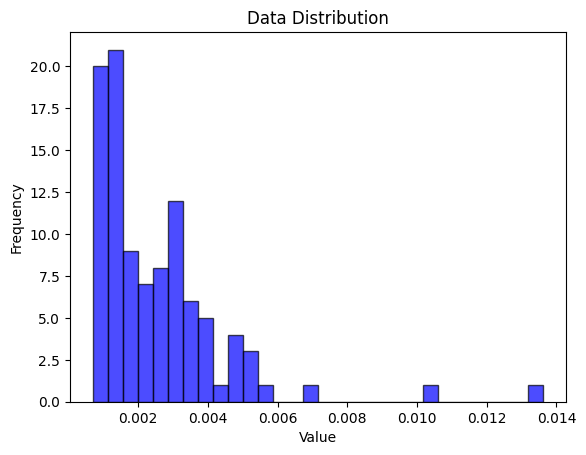

In [19]:
loss_3 = convergence_data_interpret("EXP003", data_list)

Mean loss: 0.0017870104002185904
Standard deviation: 0.001246236783867618
Mean iteration to converge: 3.09
Convergence rate: 1.0
Quartiles: [0.0008059137257495254, 0.0011306290289186146, 0.0025809615070439638]
IQR: 0.0017750477812944385
Unconverged data: []


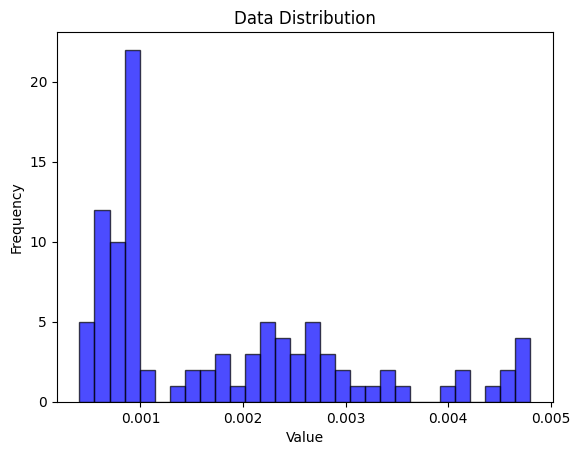

In [20]:
loss_4 = convergence_data_interpret("EXP004", data_list)

Mean loss: 1.4247260258703074
Standard deviation: 2.4773456897555257
Mean iteration to converge: 3.6595744680851063
Convergence rate: 0.94
Quartiles: [0.5673086839396929, 0.9409647148149354, 1.4158859592890336]
IQR: 0.8485772753493407
Unconverged data: [17, 25, 38, 54, 59, 61]


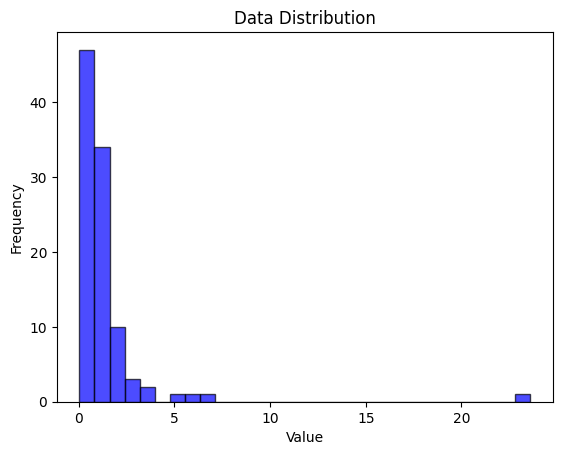

In [21]:
loss_5 = convergence_data_interpret("EXP005", data_list, fluctuation_threshold=2)

Mean loss: 8.137404585870375e-07
Standard deviation: 7.973787432988749e-06
Mean iteration to converge: 3.38
Convergence rate: 1.0
Quartiles: [1.6036829340609908e-10, 8.580972497390478e-10, 7.617389518932253e-09]
IQR: 7.457021225526154e-09
Unconverged data: []


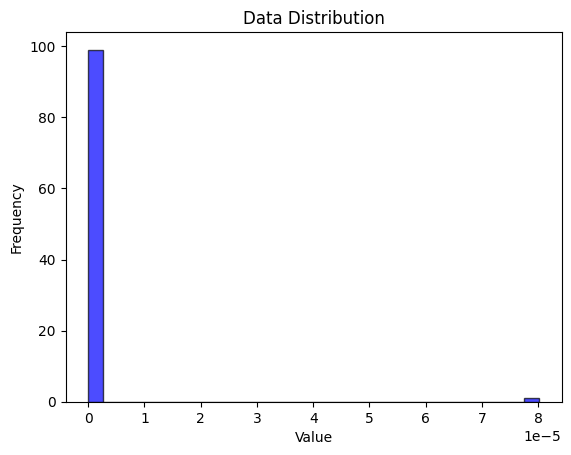

In [22]:
loss_6 = convergence_data_interpret("EXP006", data_list, fluctuation_threshold=2)

Mean loss: 3.4844836797809147
Standard deviation: 2.59589112641482
Mean iteration to converge: 3.1875
Convergence rate: 0.96
Quartiles: [1.4484166092216755, 2.6508398480613873, 4.850917860252802]
IQR: 3.4025012510311266
Unconverged data: [17, 23, 54, 59]


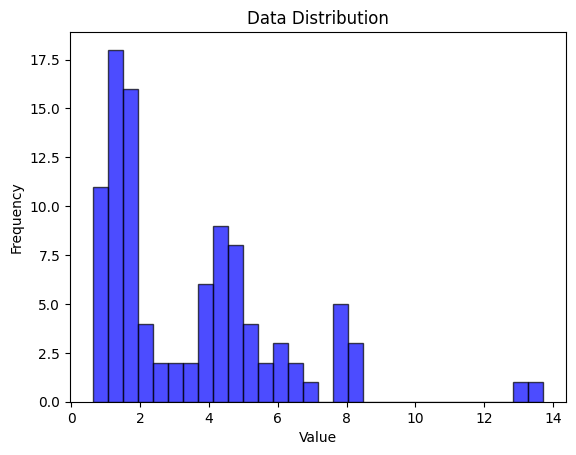

In [23]:
loss_7 = convergence_data_interpret("EXP007", data_list, fluctuation_threshold=2)

Mean loss: 2.838688643756569
Standard deviation: 2.2341992474069556
Mean iteration to converge: 2.93
Convergence rate: 1.0
Quartiles: [1.1058049506770111, 1.5136396414326416, 4.288764392704204]
IQR: 3.182959442027193
Unconverged data: []


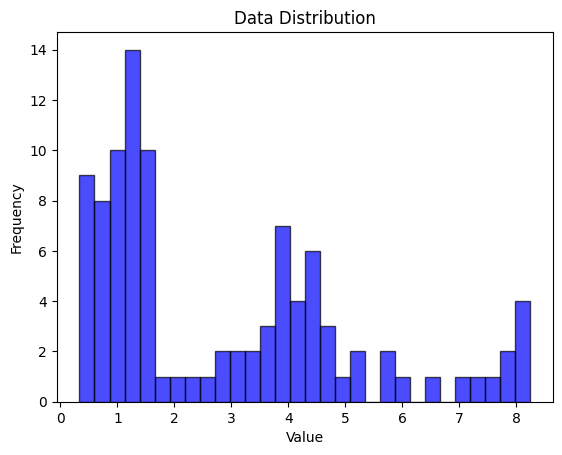

In [24]:
loss_8 = convergence_data_interpret("EXP008", data_list, fluctuation_threshold=2)

Mean loss: 0.02132952540655492
Standard deviation: 0.015699543072448235
Mean iteration to converge: 2.58
Convergence rate: 1.0
Quartiles: [0.009251618617551067, 0.018224331852114604, 0.028701950699820112]
IQR: 0.019450332082269046
Unconverged data: []


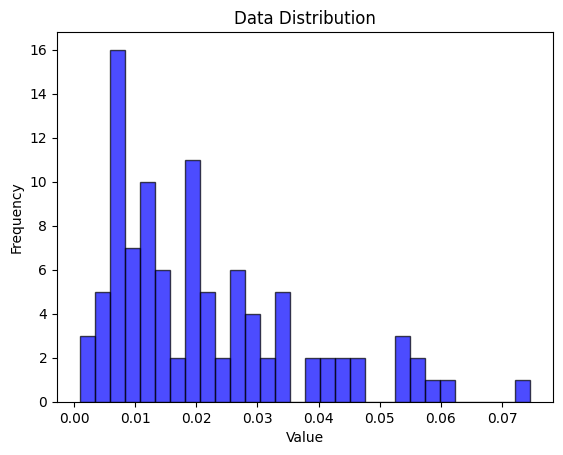

In [25]:
loss_11 = convergence_data_interpret("EXP011", data_list)

Mean loss: 0.012722998765687712
Standard deviation: 0.008379098226918997
Mean iteration to converge: 2.48
Convergence rate: 1.0
Quartiles: [0.0068222292418178045, 0.010291508551877635, 0.01804470351909345]
IQR: 0.011222474277275647
Unconverged data: []


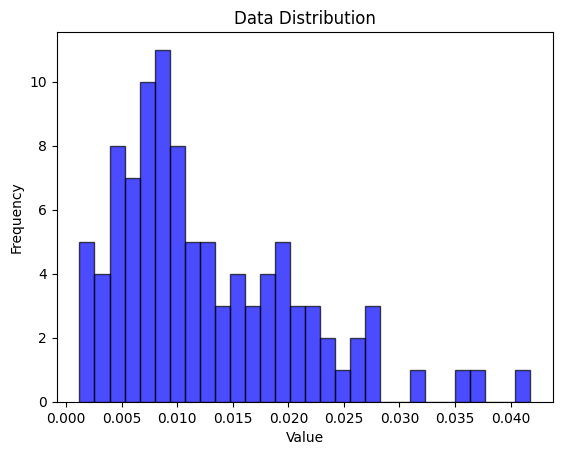

In [26]:
loss_12 = convergence_data_interpret("EXP012", data_list)

Mean loss: 22.505821585587082
Standard deviation: 18.75640005062962
Mean iteration to converge: 2.54
Convergence rate: 1.0
Quartiles: [9.477760966371992, 16.449847138785834, 28.527246372811703]
IQR: 19.04948540643971
Unconverged data: []


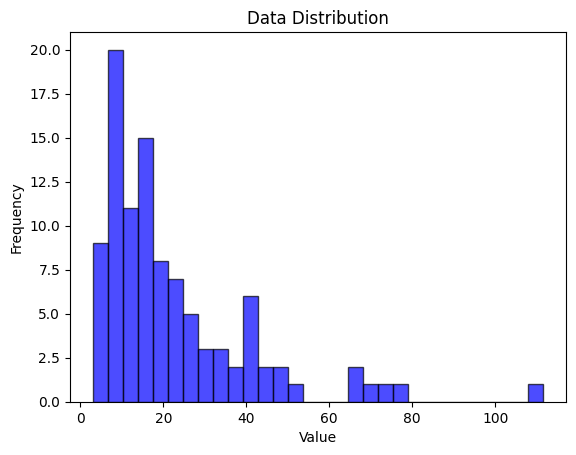

In [27]:
loss_13 = convergence_data_interpret("EXP013", data_list, fluctuation_threshold=2)

Mean loss: 12.858196356858368
Standard deviation: 6.334727284231324
Mean iteration to converge: 2.35
Convergence rate: 1.0
Quartiles: [7.908376702282725, 11.61271763396223, 15.989750083546499]
IQR: 8.081373381263774
Unconverged data: []


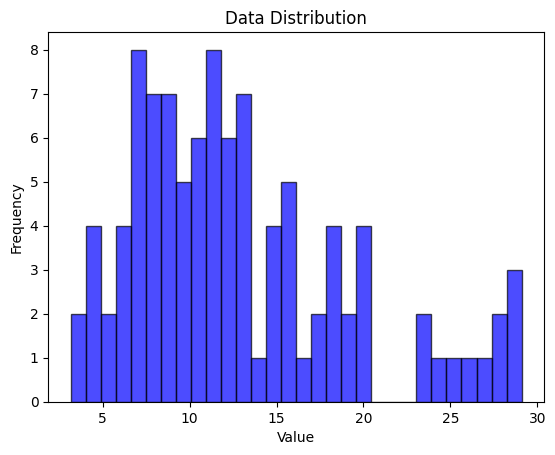

In [28]:
loss_14 = convergence_data_interpret("EXP014", data_list, fluctuation_threshold=2)

In [29]:
def box_plot(data1, data2, data3, data4, ylabel, xticklabels):
    """
    Create a box plot comparing two groups of data.

    Parameters:
    data1, data2, data3, data4: list of lists
        Data for each box plot category.
    ylabel: str
        Label for the y-axis.
    xticklabels: list of str
        Labels for the x-axis categories.
    """

    # Grouping data
    data_group1 = [data1, data2]  # First group
    data_group2 = [data3, data4]  # Second group

    # Define colors
    color_recon = "#1f77b4"  # Blue for reconstruction
    color_gt = "#ff7f0e"  # Orange for ground truth

    # Create figure and axis
    fig, ax = plt.subplots(dpi=300)

    # Plot the first group of data
    box1 = ax.boxplot(
        data_group1,
        positions=[1, 2],
        widths=0.6,
        patch_artist=False,  # Do not fill the boxes
        showfliers=False  # Do not display outliers
    )

    # Plot the second group of data
    box2 = ax.boxplot(
        data_group2,
        positions=[4, 5],
        widths=0.6,
        patch_artist=False,  # Do not fill the boxes
        showfliers=False  # Do not display outliers
    )

    # Customize box plot colors: 
    # - First and third boxes are blue
    # - Second and fourth boxes are orange
    for i, color in enumerate([color_recon, color_gt, color_recon, color_gt]):
        box = box1 if i < 2 else box2
        index = i % 2  # Index within the group
        plt.setp(box["boxes"][index], color=color)  # Set box border color
        plt.setp(box["whiskers"][2*index:2*index+2], color=color)  # Set whisker color
        plt.setp(box["caps"][2*index:2*index+2], color=color)  # Set cap color
        plt.setp(box["medians"][index], color=color)  # Set median line color

    # Set x-axis ticks and labels
    ax.set_xticks([1.5, 4.5])  # Center position for each group
    ax.set_xticklabels(xticklabels)  # Assign group labels
    
    ax.yaxis.set_major_locator(plt.MultipleLocator(1))  # Set y-axis tick interval

    # Add grid lines
    ax.grid(axis="y", linestyle="--", alpha=0.7)
    ax.grid(axis="x", linestyle="--", alpha=0.7)

    # Add legend
    custom_legend = [
        plt.Line2D([0], [0], color=color_recon, lw=2, label="Reconstruction"),
        plt.Line2D([0], [0], color=color_gt, lw=2, label="Ground Truth")
    ]
    ax.legend(handles=custom_legend, loc="upper left", title="Feedback Type")

    # Set axis labels
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Goal Type")

    # Adjust layout and display the plot
    plt.tight_layout()
    plt.show()

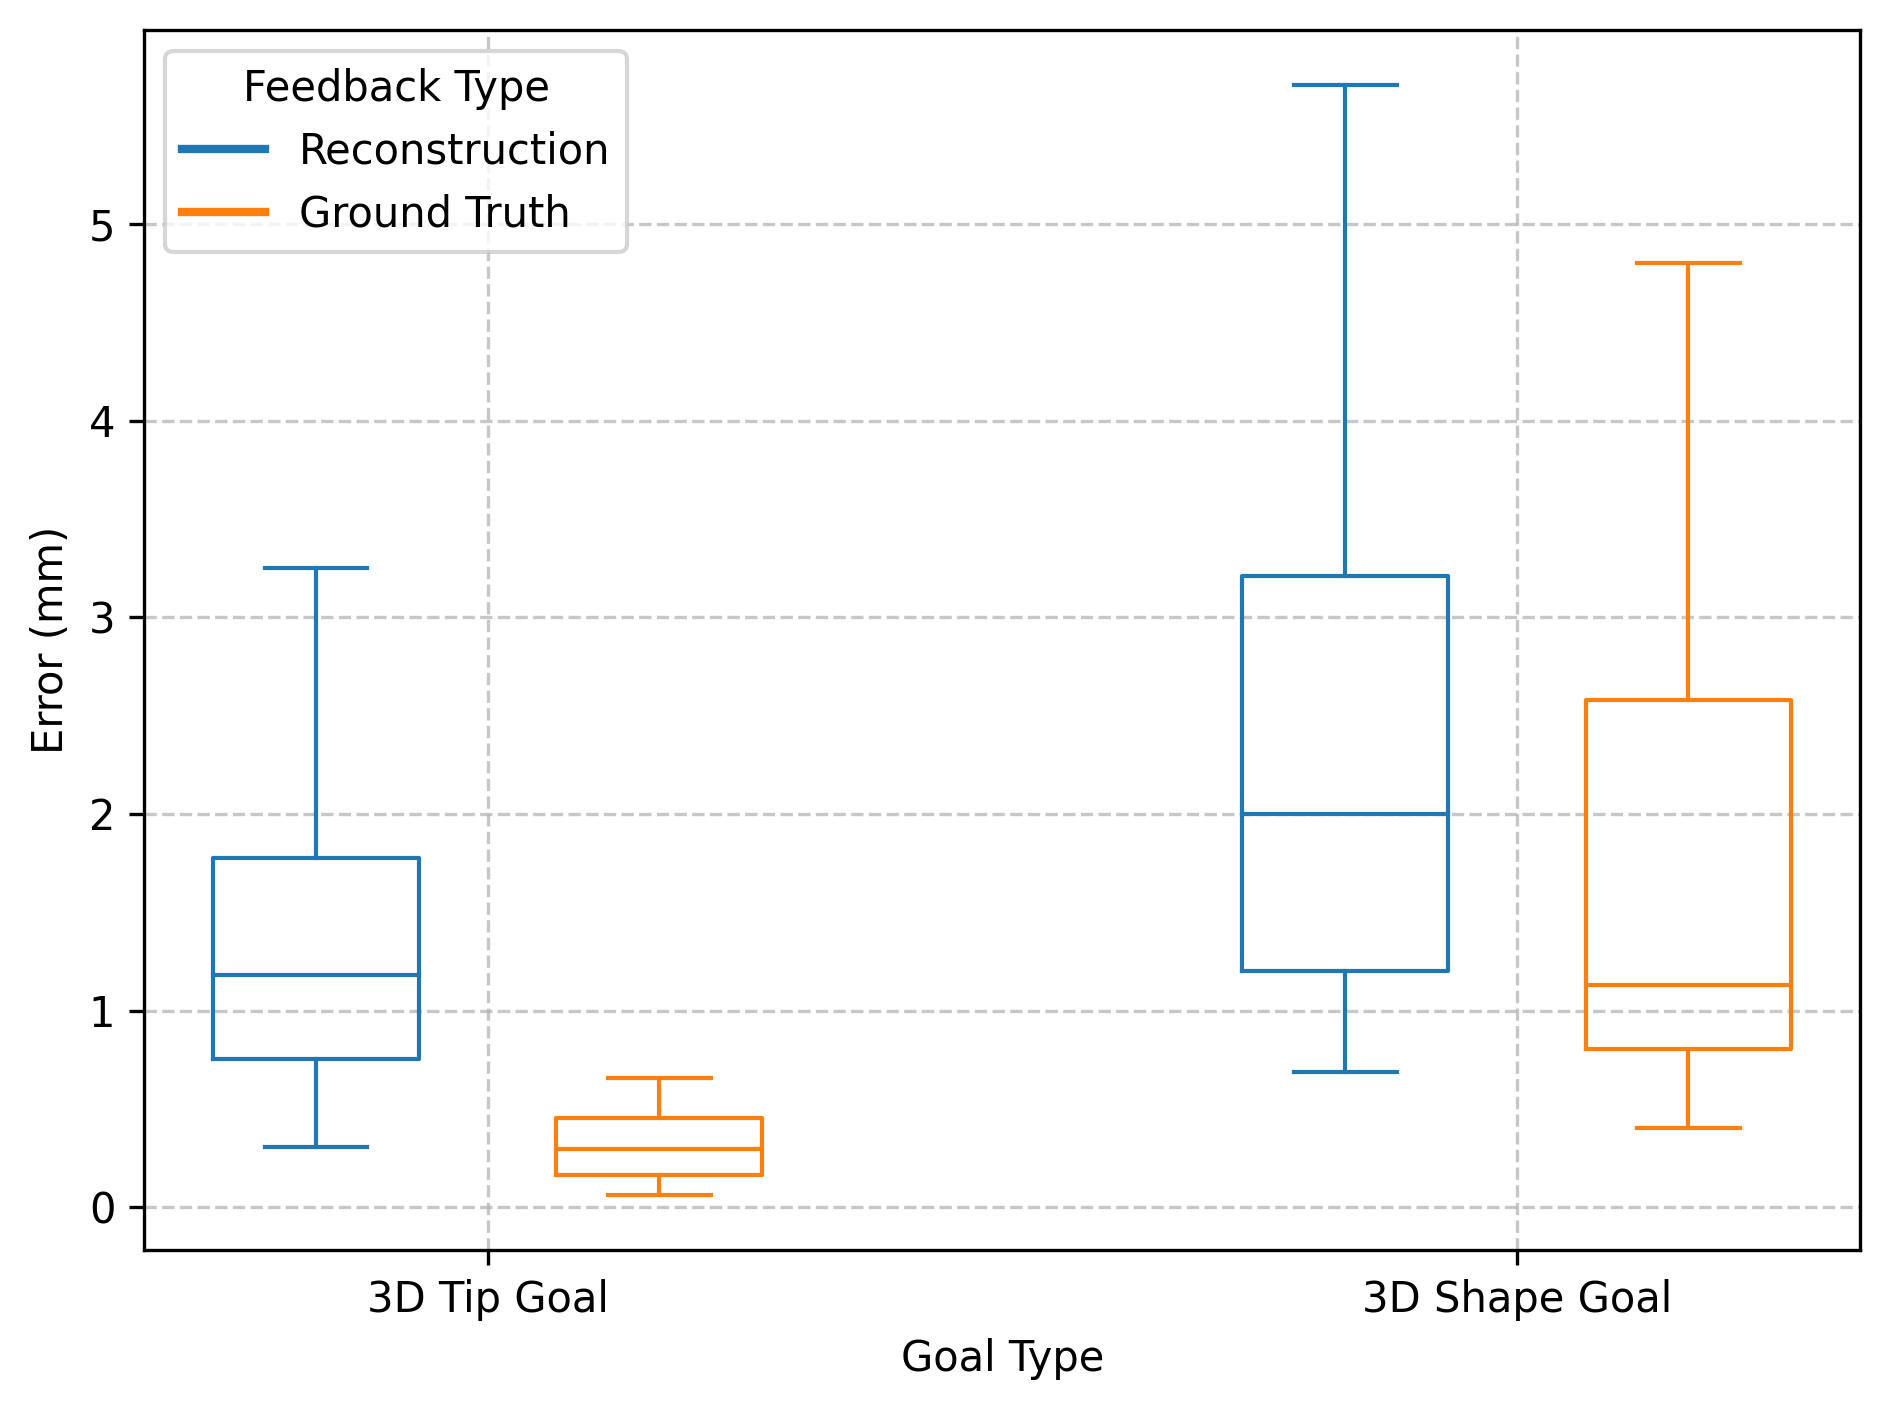

In [30]:
data1 = [x * 1000 for x in loss_1]
data2 = [x * 1000 for x in loss_2]
data3 = [x * 1000 for x in loss_3]
data4 = [x * 1000 for x in loss_4]

box_plot(data1, data2, data3, data4, "Error (mm)", ["3D Tip Goal", "3D Shape Goal"])

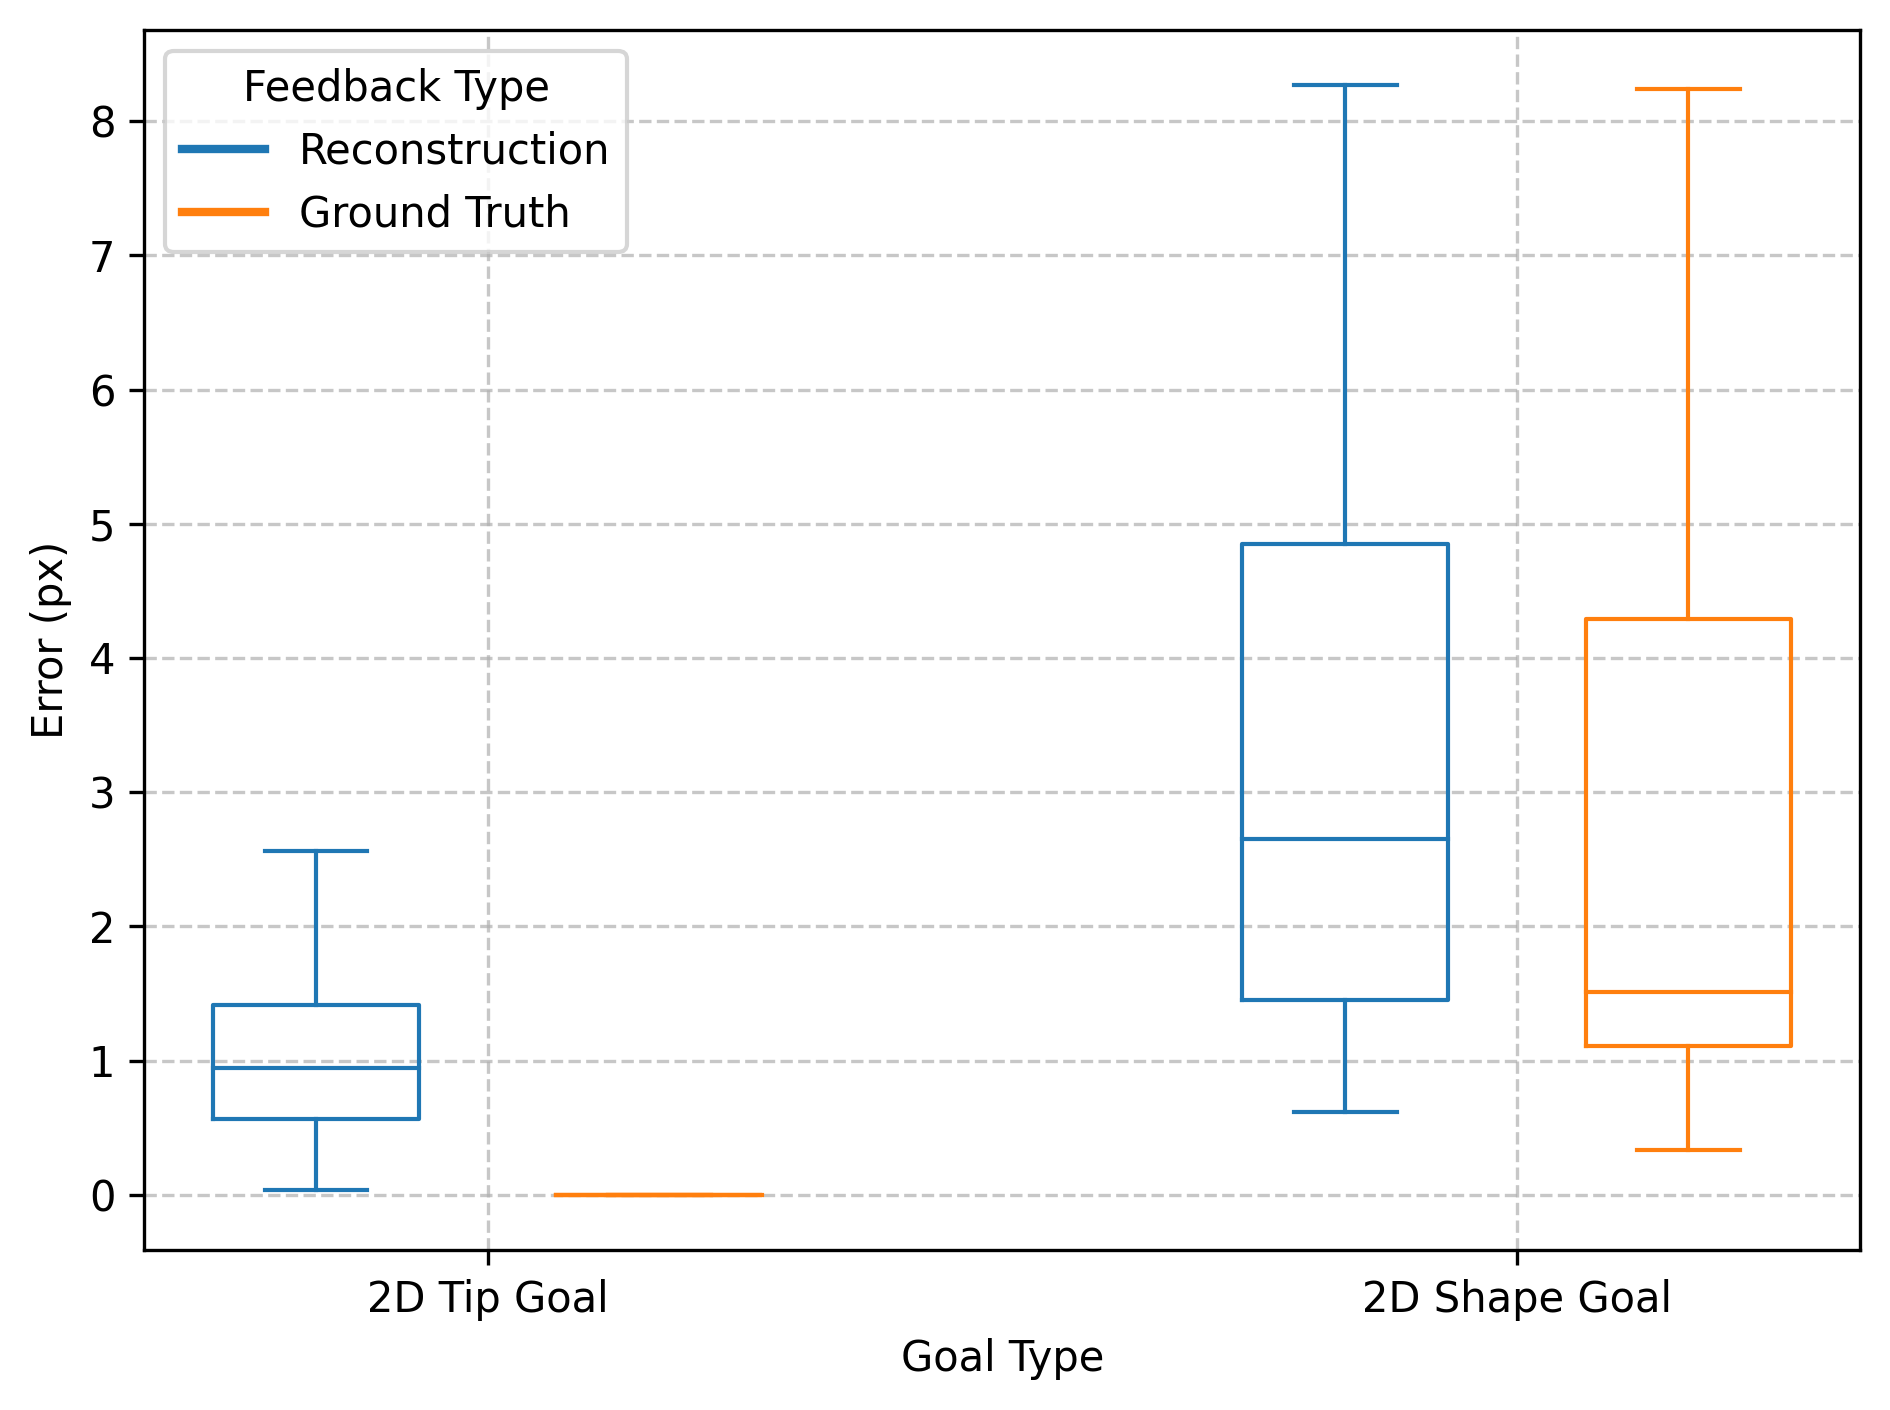

In [31]:
box_plot(loss_5, loss_6, loss_7, loss_8, "Error (px)", ["2D Tip Goal", "2D Shape Goal"])

In [32]:
def box_plot2(data1, data2, data3, data4, data5, data6, ylabel, xticklabels, log=False):
    """
    Draw a box plot for six datasets, grouped into two categories, with different colors.

    Parameters:
    - data1, data2, data3, data4, data5, data6: Six datasets for plotting. 
      Order: tip gt, tip recon, tip theory, shape gt, shape recon, shape theory.
    - ylabel: Label for the y-axis.
    - xticklabels: Labels for the x-axis groups (e.g., Group 1 and Group 2).
    """

    data_group1 = [data1, data2, data3]  # Group 1
    data_group2 = [data4, data5, data6]  # Group 2

    # Define colors
    color_recon = "#1f77b4"  # Blue (Reconstruction)
    color_gt = "#ff7f0e"  # Orange (Ground Truth)
    color_theory = "#2ca02c"  # Green (Theory)

    # colors = [color_recon, color_gt, color_theory, color_recon, color_gt, color_theory]
    colors = [color_gt, color_recon, color_theory, color_gt, color_recon, color_theory]

    # Create figure
    fig, ax = plt.subplots(dpi=300)

    # Draw box plot for Group 1
    box1 = ax.boxplot(
        data_group1,
        positions=[1, 2, 3],
        widths=0.6,
        patch_artist=False,  # Keep simple box style
        showfliers=False  # Hide outliers
    )

    # Draw box plot for Group 2
    box2 = ax.boxplot(
        data_group2,
        positions=[5, 6, 7],
        widths=0.6,
        patch_artist=False,  # Keep simple box style
        showfliers=False  # Hide outliers
    )

    # Modify colors for each dataset
    for i, color in enumerate(colors):
        box = box1 if i < 3 else box2  # First 3 datasets belong to Group 1, last 3 to Group 2
        index = i % 3  # Index within the group
        plt.setp(box["boxes"][index], color=color)  # Set box border color
        plt.setp(box["whiskers"][2*index:2*index+2], color=color)  # Set whisker color
        plt.setp(box["caps"][2*index:2*index+2], color=color)  # Set cap color
        plt.setp(box["medians"][index], color=color)  # Set median line color

    # Set x-axis ticks and labels
    ax.set_xticks([2, 6])  # Center position for each group
    ax.set_xticklabels(xticklabels)  # Set x-axis labels

    # Adjust y-axis tick locator
    ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

    # Add grid lines
    ax.grid(axis="y", linestyle="--", alpha=0.7)
    ax.grid(axis="x", linestyle="--", alpha=0.7)

    # Add legend
    custom_legend = [
        plt.Line2D([0], [0], color=color_gt, lw=2, label="Ground Truth"),
        plt.Line2D([0], [0], color=color_recon, lw=2, label="Reconstruction"),
        plt.Line2D([0], [0], color=color_theory, lw=2, label="Model")
    ]
    ax.legend(handles=custom_legend, loc="upper left", title="Feedback Type")

    # Set y-axis label
    ax.set_ylabel(ylabel)

    # Set x-axis label
    ax.set_xlabel("Goal Type")
    
    if log:
        ax.set_yscale("log")

    # Adjust layout
    plt.tight_layout()

    # Show plot
    plt.show()

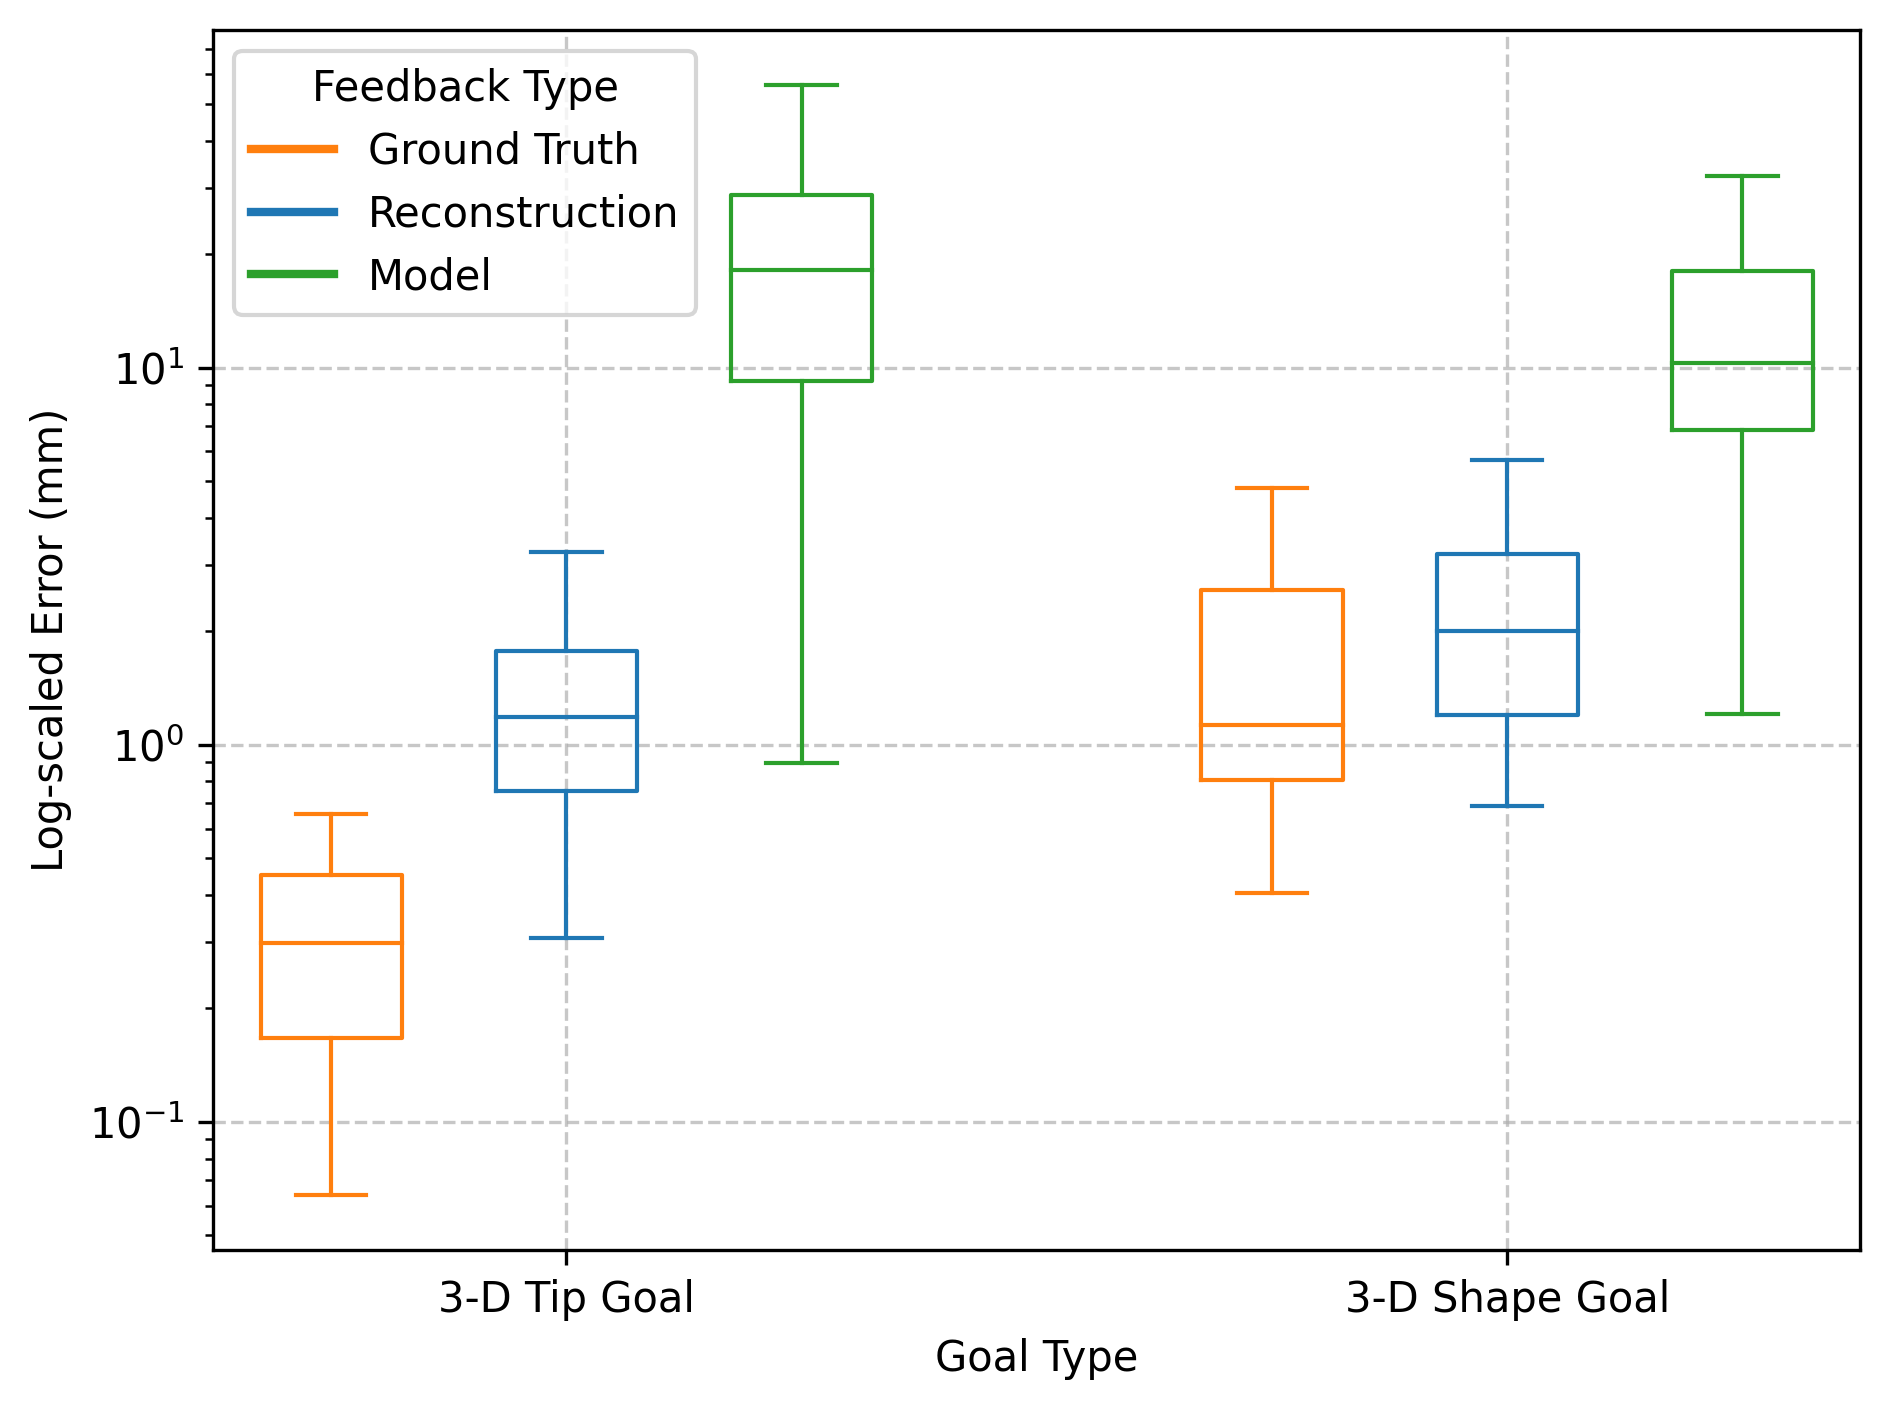

In [33]:
data1 = [x * 1000 for x in loss_2]
data2 = [x * 1000 for x in loss_1]
data3 = [x * 1000 for x in loss_11]
data4 = [x * 1000 for x in loss_4]
data5 = [x * 1000 for x in loss_3]
data6 = [x * 1000 for x in loss_12]

box_plot2(data1, data2, data3, data4, data5, data6, "Log-scaled Error (mm)", ["3-D Tip Goal", "3-D Shape Goal"], log=True)

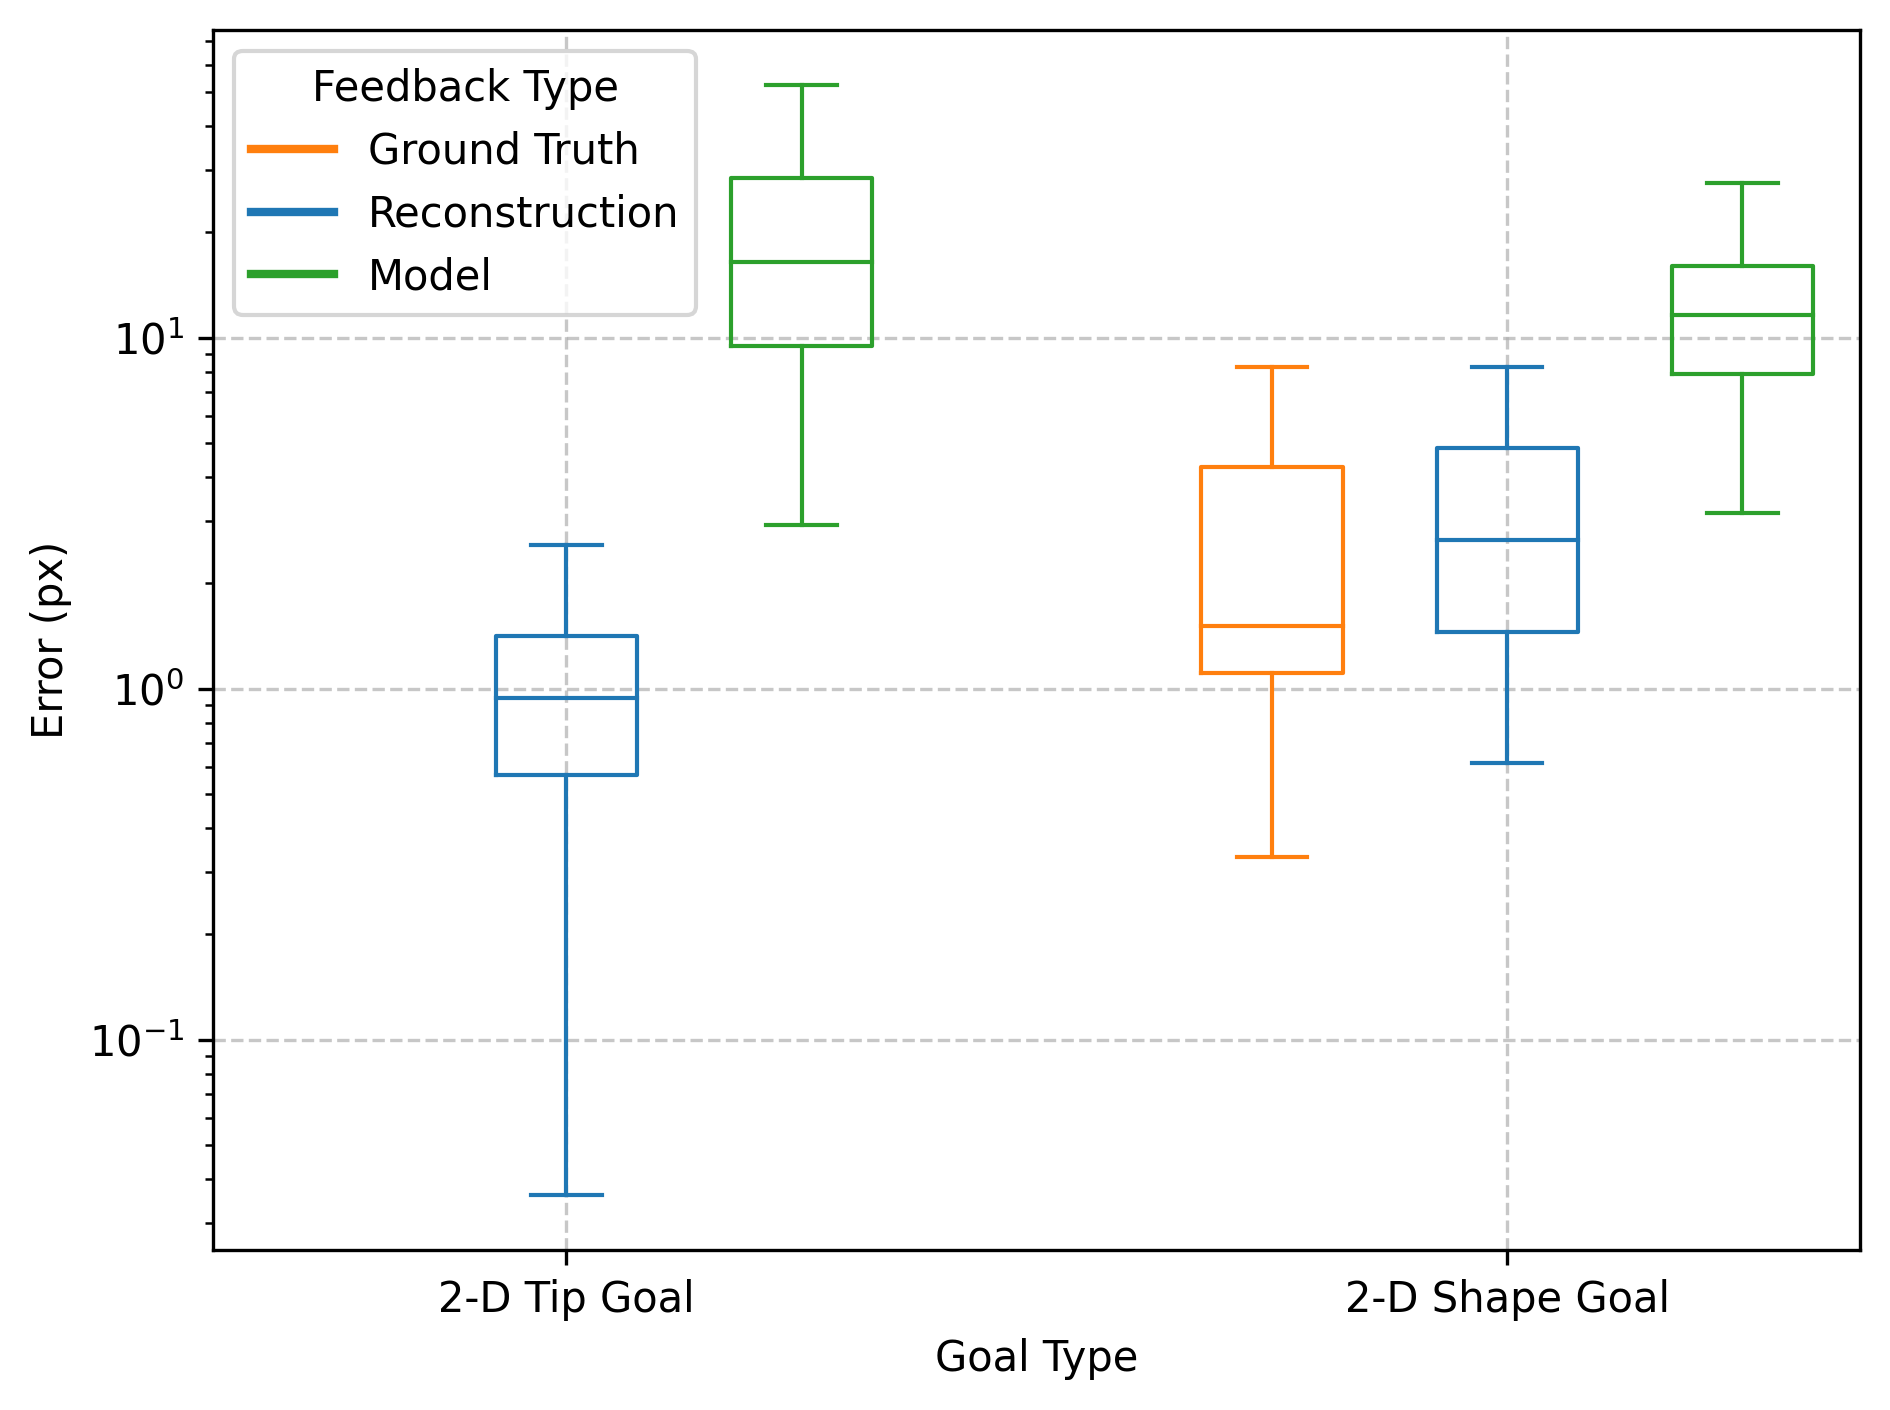

In [34]:
data1 = [x * 0 for x in loss_6]
box_plot2(data1, loss_5, loss_13, loss_8, loss_7, loss_14, "Error (px)", ["2-D Tip Goal", "2-D Shape Goal"], log=True)